<a href="https://colab.research.google.com/github/amasha-sinhalagoda/J26-IT-334/blob/model%2Fcp_landslide/Landslide_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*This is My NoteBook that I Implement and Build My Model . My component Is Landslide Risk Assetment For Sri Lanka - Bagya R M S*

# Spatial Validation Methodology: Blocks & Folds

To ensure our landslide predictive models generalize well to unseen geographic areas, we implement a **Spatial Cross-Validation** strategy rather than standard random train-test splitting (which suffers from spatial autocorrelation bias).

### 1. Spatial Blocks (`block_id`)
* Our study area in Sri Lanka is divided into distinct geographic grids or blocks, identified by the `block_id` (e.g., `66_70`).
* Each block groups geographically adjacent observations together.

### 2. Spatial Cross-Validation Folds (`fold`)
* Individual observations are assigned to a fold from `0` to `4` based on their `block_id`.
* **Block-based Partitioning:** All data points belonging to the same `block_id` are kept together in the same fold.
* **Why this is critical:** During training, entire geographic blocks are held out together. This simulates predicting landslide susceptibility in entirely unmapped areas, providing an honest and scientifically rigorous estimation of model accuracy.

*Importing libraries That Need For implementations*

In [3]:
import pandas as pd

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
sns.set_theme(style='whitegrid')

*Import Datasets Into my Note Book landslide_rainfall_model_dataset*

In [5]:
df = pd.read_csv('/content/landslide_static_model_dataset.csv')

print(df.shape)
display(df.head())
print(df.info())

(5597, 17)


,label,fold,block_id,soil_clay_0_30,soil_sand_0_30,soil_silt_0_30,soil_oc_0_30,soil_ph_0_30,soil_bd_0_30,soil_awc_0_30,soil_clay_gradient,soil_cec_0_30,soil_clay_60_100,bench_lhmp_class,diag_nearest_gauge_km,meta_lat,meta_lon
0,1,4,66_70,23.99696,53.11716,20.90986,2.11253,5.33985,1.22577,0.06172,9.25907,15.30557,30.97781,2.0,0.70095,7.098072,80.756045
1,1,4,65_70,23.84051,54.35036,20.01871,1.51113,5.39450,1.25873,0.05892,8.00685,14.15983,29.81838,3.0,1.07428,7.109057,80.746482
2,1,4,66_70,23.99696,53.11716,20.90986,2.11253,5.33985,1.22577,0.06172,9.25907,15.30557,30.97781,2.0,0.63560,7.099661,80.755744
3,1,4,65_70,23.99696,53.11716,20.90986,2.11253,5.33985,1.22577,0.06172,9.25907,15.30557,30.97781,2.0,0.39824,7.098072,80.753045
4,1,3,67_72,22.30682,57.88093,18.38064,1.51489,5.55341,1.28142,0.05545,7.89976,14.52311,28.72892,1.0,5.44532,7.151016,80.790857


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5597 entries, 0 to 5596
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   label                  5597 non-null   int64  
 1   fold                   5597 non-null   int64  
 2   block_id               5597 non-null   object 
 3   soil_clay_0_30         5597 non-null   float64
 4   soil_sand_0_30         5597 non-null   float64
 5   soil_silt_0_30         5597 non-null   float64
 6   soil_oc_0_30           5597 non-null   float64
 7   soil_ph_0_30           5597 non-null   float64
 8   soil_bd_0_30           5597 non-null   float64
 9   soil_awc_0_30          5597 non-null   float64
 10  soil_clay_gradient     5597 non-null   float64
 11  soil_cec_0_30          5597 non-null   float64
 12  soil_clay_60_100       5597 non-null   float64
 13  bench_lhmp_class       5427 non-null   float64
 14  diag_nearest_gauge_km  5597 non-null   float64
 15  meta

In [6]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))
print(df.isnull().sum())
print(df['fold'].value_counts())

label
0    4398
1    1199
Name: count, dtype: int64
label
0    0.785778
1    0.214222
Name: proportion, dtype: float64
label                      0
fold                       0
block_id                   0
soil_clay_0_30             0
soil_sand_0_30             0
soil_silt_0_30             0
soil_oc_0_30               0
soil_ph_0_30               0
soil_bd_0_30               0
soil_awc_0_30              0
soil_clay_gradient         0
soil_cec_0_30              0
soil_clay_60_100           0
bench_lhmp_class         170
diag_nearest_gauge_km      0
meta_lat                   0
meta_lon                   0
dtype: int64
fold
0    1196
4    1150
1    1105
3    1094
2    1052
Name: count, dtype: int64


*Check Class Imbalance and Missing Values*

In [7]:
print('landslide share:', round(df.label.mean(), 3))
print(df.label.value_counts())
print('\nmissing values:')
print(df.isna().sum()[lambda s: s > 0])

landslide share: 0.214
label
0    4398
1    1199
Name: count, dtype: int64

missing values:
bench_lhmp_class    170
dtype: int64


*Check The spatial folds*

In [8]:
blocks_in_many_folds = (df.groupby('block_id').fold.nunique() > 1).sum()
print('blocks in more than one fold:', blocks_in_many_folds)

df.groupby('fold').label.agg(rows='size', landslides='sum', share='mean').round(3)

blocks in more than one fold: 0


,rows,landslides,share
fold,,,
0,1196,212,0.177
1,1105,317,0.287
2,1052,143,0.136
3,1094,147,0.134
4,1150,380,0.330


*Find the duplication Rows*

In [9]:
print('exact duplicate rows:', df.duplicated().sum())
print('duplicates among landslides:', df[df.label == 1].duplicated().sum())
print('duplicates among non-landslides:', df[df.label == 0].duplicated().sum())

exact duplicate rows: 160
duplicates among landslides: 160
duplicates among non-landslides: 0


*Remove That found Dupliation Rows*

In [10]:
clean = df.drop_duplicates().reset_index(drop=True)
print('after removing duplicates:', clean.shape)
print('landslides:', int(clean.label.sum()), '| share:', round(clean.label.mean(), 3))
clean.to_csv('static_clean_step1.csv', index=False)

after removing duplicates: (5437, 17)
landslides: 1039 | share: 0.191


*define feature groups and check correlation*

['soil_clay_0_30', 'soil_sand_0_30', 'soil_silt_0_30', 'soil_oc_0_30', 'soil_ph_0_30', 'soil_bd_0_30', 'soil_awc_0_30', 'soil_clay_gradient', 'soil_cec_0_30', 'soil_clay_60_100']


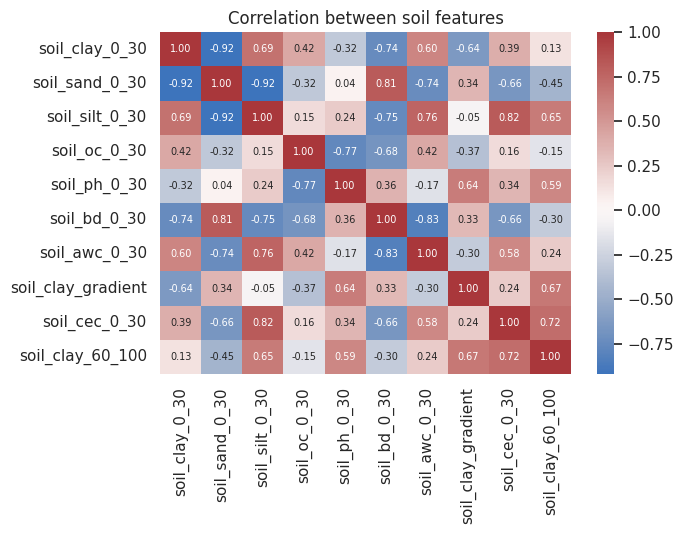

In [11]:
SOIL = [c for c in clean.columns if c.startswith('soil_')]
print(SOIL)

plt.figure(figsize=(7, 5.5))
sns.heatmap(clean[SOIL].corr(), annot=True, fmt='.2f', cmap='vlag', center=0, annot_kws={'size': 7})
plt.title('Correlation between soil features')
plt.tight_layout()
plt.show()

In [12]:
print('unique soil vectors:', clean[SOIL].drop_duplicates().shape[0], 'of', len(clean), 'rows')

clean.groupby('label')[SOIL].mean().T.round(2)

unique soil vectors: 1570 of 5437 rows


label,0,1
soil_clay_0_30,22.74,22.90
soil_sand_0_30,57.61,57.21
soil_silt_0_30,18.35,18.65
soil_oc_0_30,2.08,2.05
soil_ph_0_30,5.29,5.31
soil_bd_0_30,1.23,1.22
soil_awc_0_30,0.06,0.06
soil_clay_gradient,5.27,5.55
soil_cec_0_30,14.19,14.51
soil_clay_60_100,26.31,27.02


***distribution plots***

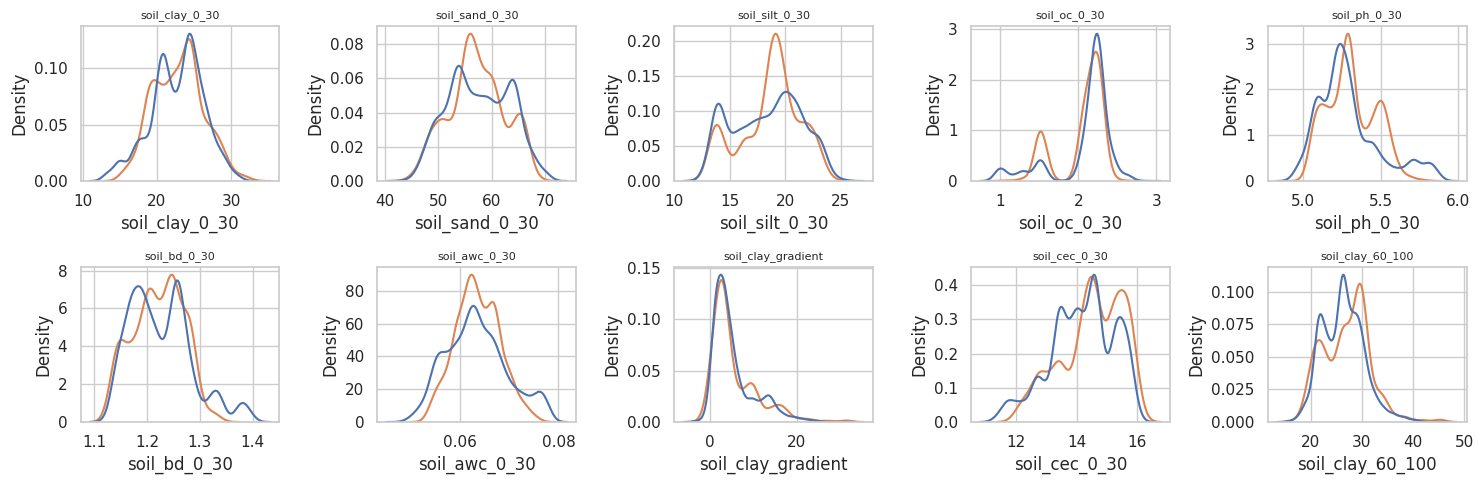

In [13]:
fig, ax = plt.subplots(2, 5, figsize=(15, 5))
for a, c in zip(ax.ravel(), SOIL):
    sns.kdeplot(data=clean, x=c, hue='label', common_norm=False, ax=a, legend=False)
    a.set_title(c, fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
b = clean.dropna(subset=['bench_lhmp_class'])
print('NBRI hazard class AUC:', round(roc_auc_score(b.label, b.bench_lhmp_class), 3))
pd.crosstab(b.bench_lhmp_class, b.label, normalize='index').round(2)

NBRI hazard class AUC: 0.512


label,0,1
bench_lhmp_class,,
1.0,0.82,0.18
2.0,0.80,0.20
3.0,0.81,0.19
4.0,0.79,0.21


***load the cleaned data and define features***

In [15]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
df = pd.read_csv('static_clean_step1.csv')
y = df.label.values

SOIL   = [c for c in df.columns if c.startswith('soil_')]
SOIL_LR = [c for c in SOIL if c != 'soil_sand_0_30']   # drop sand for logistic regression
COORDS = ['meta_lat', 'meta_lon']
print(len(df), 'rows |', int(y.sum()), 'landslides')

5437 rows | 1039 landslides


*build the two spatial validation schemes*

In [16]:
# Scheme A: your 3 km blocks (the 'fold' column)
# Scheme B: leave one whole region out (5 regions from k-means on coordinates)
df['region'] = KMeans(5, n_init=10, random_state=SEED).fit_predict(df[COORDS])

idx = np.arange(len(df))
SPLITS = {
    'block3km': [(idx[df.fold != k],   idx[df.fold == k])   for k in sorted(df.fold.unique())],
    'region':   [(idx[df.region != k], idx[df.region == k]) for k in range(5)],
}
for name, sp in SPLITS.items():
    print(name, '| landslides per test fold:', [int(y[te].sum()) for _, te in sp])

block3km | landslides per test fold: [182, 267, 129, 128, 333]
region | landslides per test fold: [91, 309, 366, 103, 170]


### Visualizing the Spatial Splits
To understand why we do not need a simple random train/test split, let's visualize the spatial clusters (`regions`) created by the K-Means algorithm. Each region represents a geographic fold used in our Leave-One-Region-Out cross-validation.

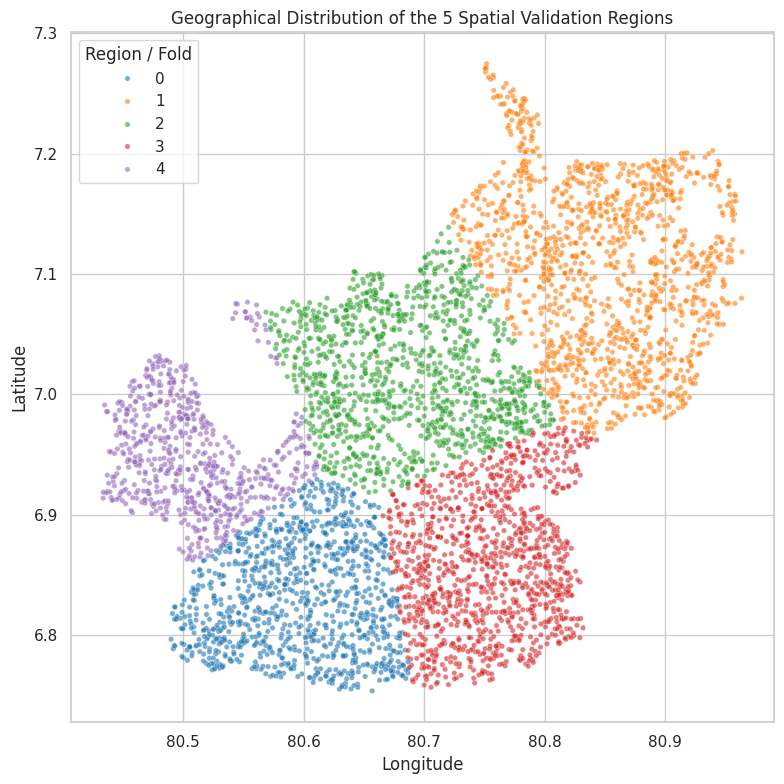

In [21]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df,
    x='meta_lon',
    y='meta_lat',
    hue='region',
    palette='tab10',
    alpha=0.6,
    s=15
)
plt.title('Geographical Distribution of the 5 Spatial Validation Regions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Region / Fold')
plt.tight_layout()
plt.show()

# ***define the models***

In [44]:

SEED = 42

# Define the FACTORY dictionary with Logistic Regression, XGBoost, and LightGBM
FACTORY = {
    'LogReg': lambda: make_pipeline(StandardScaler(), LogisticRegression(C=0.3, max_iter=3000, random_state=SEED)),
    'XGBoost': lambda: XGBClassifier(
        n_estimators=250,
        max_depth=3,
        learning_rate=0.04,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        reg_lambda=5,
        eval_metric='logloss',
        n_jobs=2,
        random_state=SEED
    ),
    'LightGBM': lambda: LGBMClassifier(
        n_estimators=250,
        max_depth=3,
        num_leaves=8,
        learning_rate=0.04,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        min_child_samples=40,
        reg_lambda=5,
        verbose=-1,
        n_jobs=2,
        random_state=SEED
    )
}

# Define the feature sets
SOIL = [c for c in df_clean.columns if c.startswith('soil_')]
SOIL_LR = [c for c in SOIL if c != 'soil_sand_0_30']
COORDS = ['meta_lat', 'meta_lon']

# Establish the EXPERIMENTS dictionary (excluding neural networks)
EXPERIMENTS = {
    'LogReg (soil)':          (SOIL_LR, 'LogReg'),
    'XGBoost (soil)':         (SOIL,    'XGBoost'),
    'LightGBM (soil)':        (SOIL,    'LightGBM'),
    'LightGBM (coords only)': (COORDS,  'LightGBM')
}

print("FACTORY and EXPERIMENTS dictionaries have been successfully defined without neural networks.")

FACTORY and EXPERIMENTS dictionaries have been successfully defined without neural networks.


In [45]:


df_clean['region'] = KMeans(5, n_init=10, random_state=SEED).fit_predict(df_clean[COORDS])


idx = np.arange(len(df_clean))
SPLITS = {
    'block3km': [(idx[df_clean.fold != k], idx[df_clean.fold == k]) for k in sorted(df_clean.fold.unique())],
    'region': [(idx[df_clean.region != k], idx[df_clean.region == k]) for k in range(5)],
}

#  Evaluate models on spatial validation schemes
rows = []
for scheme, sp in SPLITS.items():
    # Baseline: NBRI hazard class
    aucs = []
    for _, te in sp:
        t_fold = df_clean.iloc[te].dropna(subset=['bench_lhmp_class'])
        if len(t_fold) > 0 and len(t_fold.label.unique()) > 1:
            aucs.append(roc_auc_score(t_fold.label, t_fold.bench_lhmp_class))
        else:
            aucs.append(np.nan)
    rows.append((scheme, 'NBRI hazard class', np.nanmean(aucs), np.nanstd(aucs), np.nan))

    # Trained models
    for name, (feats, model_name) in EXPERIMENTS.items():
        aucs, aps = [], []
        for tr, te in sp:
            model = FACTORY[model_name]().fit(df_clean.iloc[tr][feats], df_clean.iloc[tr]['label'])
            p = model.predict_proba(df_clean.iloc[te][feats])[:, 1]
            aucs.append(roc_auc_score(df_clean.iloc[te]['label'], p))
            aps.append(average_precision_score(df_clean.iloc[te]['label'], p))
        rows.append((scheme, name, np.mean(aucs), np.std(aucs), np.mean(aps)))

# Create and display results DataFrame
cv_results = pd.DataFrame(rows, columns=['scheme', 'model', 'AUC_mean', 'AUC_std', 'AvgPrecision']).round(3)
print('Base rate (random AvgPrecision):', round(df_clean.label.mean(), 3))
display(cv_results)

Base rate (random AvgPrecision): 0.191


,scheme,model,AUC_mean,AUC_std,AvgPrecision
0,block3km,NBRI hazard class,0.513,0.041,NaN
1,block3km,LogReg (soil),0.604,0.064,0.244
2,block3km,XGBoost (soil),0.734,0.032,0.375
3,block3km,LightGBM (soil),0.735,0.029,0.373
4,block3km,LightGBM (coords only),0.711,0.022,0.359
5,region,NBRI hazard class,0.489,0.023,NaN
6,region,LogReg (soil),0.526,0.103,0.218
7,region,XGBoost (soil),0.578,0.083,0.238
8,region,LightGBM (soil),0.551,0.070,0.229
9,region,LightGBM (coords only),0.549,0.110,0.227


***Plotting The ROC Curves***

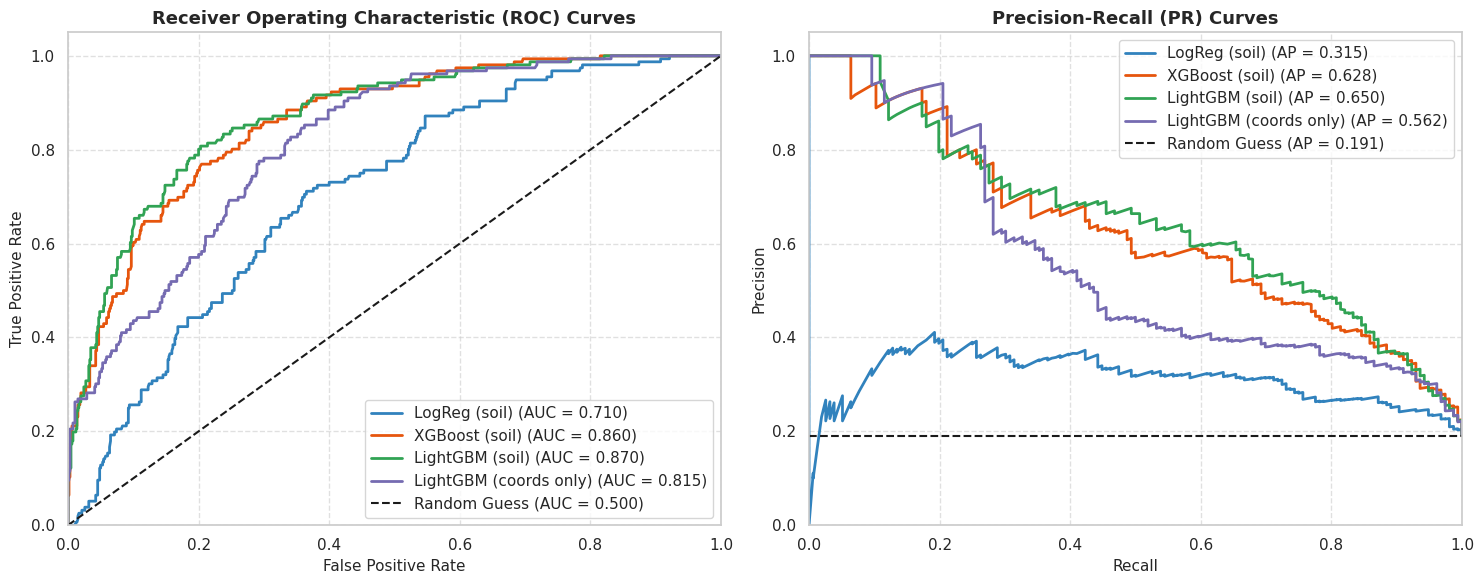

,Model,Test AUC,Test Avg Precision
0,LogReg (soil),0.709600,0.315100
1,XGBoost (soil),0.860000,0.628100
2,LightGBM (soil),0.869900,0.650300
3,LightGBM (coords only),0.815200,0.561900


In [42]:


df_clean = pd.read_csv('static_clean_step1.csv')


SOIL = [c for c in df_clean.columns if c.startswith('soil_')]
SOIL_LR = [c for c in SOIL if c != 'soil_sand_0_30']

y = df_clean['label'].values

# Split the indices to maintain structural consistency (70% train, 15% validation, 15% test)
idx_train_val, idx_test = train_test_split(
    np.arange(len(df_clean)),
    test_size=0.15,
    random_state=SEED,
    stratify=y
)
idx_train, idx_val = train_test_split(
    idx_train_val,
    test_size=15/85,
    random_state=SEED,
    stratify=y[idx_train_val]
)

test_metrics = []
curves = {}


for name, (feats, model_name) in EXPERIMENTS.items():
    # Instantiate and fit the model on the training set
    model = FACTORY[model_name]().fit(df_clean.iloc[idx_train][feats], y[idx_train])

    # Predict probability on the test set
    p_test = model.predict_proba(df_clean.iloc[idx_test][feats])[:, 1]
    y_test = y[idx_test]

    # Compute metrics
    test_auc = roc_auc_score(y_test, p_test)
    test_ap = average_precision_score(y_test, p_test)
    test_metrics.append({'Model': name, 'Test AUC': test_auc, 'Test Avg Precision': test_ap})

    # Compute curves
    fpr, tpr, _ = roc_curve(y_test, p_test)
    precision, recall, _ = precision_recall_curve(y_test, p_test)
    curves[name] = {
        'fpr': fpr, 'tpr': tpr, 'auc': test_auc,
        'precision': precision, 'recall': recall, 'ap': test_ap
    }

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = {'LogReg (soil)': '#3182bd', 'XGBoost (soil)': '#e6550d', 'LightGBM (soil)': '#31a354', 'LightGBM (coords only)': '#756bb1'}

# Subplot 1: ROC Curve
for name, data in curves.items():
    axes[0].plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['auc']:.3f})", color=colors[name], lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)', lw=1.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=13, fontweight='bold')
axes[0].legend(loc="lower right", frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Precision-Recall Curve
base_rate = y_test.mean()
for name, data in curves.items():
    axes[1].plot(data['recall'], data['precision'], label=f"{name} (AP = {data['ap']:.3f})", color=colors[name], lw=2)
axes[1].axhline(y=base_rate, color='k', linestyle='--', label=f'Random Guess (AP = {base_rate:.3f})', lw=1.5)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall (PR) Curves', fontsize=13, fontweight='bold')
axes[1].legend(loc="upper right", frameon=True)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


df_summary = pd.DataFrame(test_metrics).round(4)
display(df_summary.style.background_gradient(cmap='Greens', subset=['Test AUC', 'Test Avg Precision']))

*Extract Train and Test Performance*

In [46]:

# 1. Load clean dataset
df_clean = pd.read_csv('/content/static_clean_step1.csv')
y_full = df_clean['label'].values

# 2. Define features
SOIL = [c for c in df_clean.columns if c.startswith('soil_')]
SOIL_LR = [c for c in SOIL if c != 'soil_sand_0_30']

# 3. Use train/test indices defined previously
X_train_full = df_clean.iloc[idx_train]
y_train_full = y_full[idx_train]
X_test_full = df_clean.iloc[idx_test]
y_test_full = y_full[idx_test]

# 4. Train models and evaluate AUC-ROC on train and test splits
results_auc = []

for name, (feats, model_name) in EXPERIMENTS.items():
    if 'coords' in name:
        continue  # Only evaluate models on soil features as requested

    # Instantiate and fit
    model = FACTORY[model_name]().fit(X_train_full[feats], y_train_full)

    # Predict probabilities
    p_train = model.predict_proba(X_train_full[feats])[:, 1]
    p_test = model.predict_proba(X_test_full[feats])[:, 1]

    # Calculate AUCs
    train_auc = roc_auc_score(y_train_full, p_train)
    test_auc = roc_auc_score(y_test_full, p_test)

    results_auc.append({
        'Model': name,
        'Train AUC-ROC': train_auc,
        'Test AUC-ROC': test_auc,
        'Difference (Overfitting Gap)': train_auc - test_auc
    })

# 5. Display results
df_auc_summary = pd.DataFrame(results_auc).round(4)
display(df_auc_summary)

,Model,Train AUC-ROC,Test AUC-ROC,Difference (Overfitting Gap)
0,LogReg (soil),0.6726,0.7096,-0.0370
1,XGBoost (soil),0.9013,0.8600,0.0413
2,LightGBM (soil),0.9046,0.8699,0.0347


*Visualizing the Training vs. Test Performance Gaps*

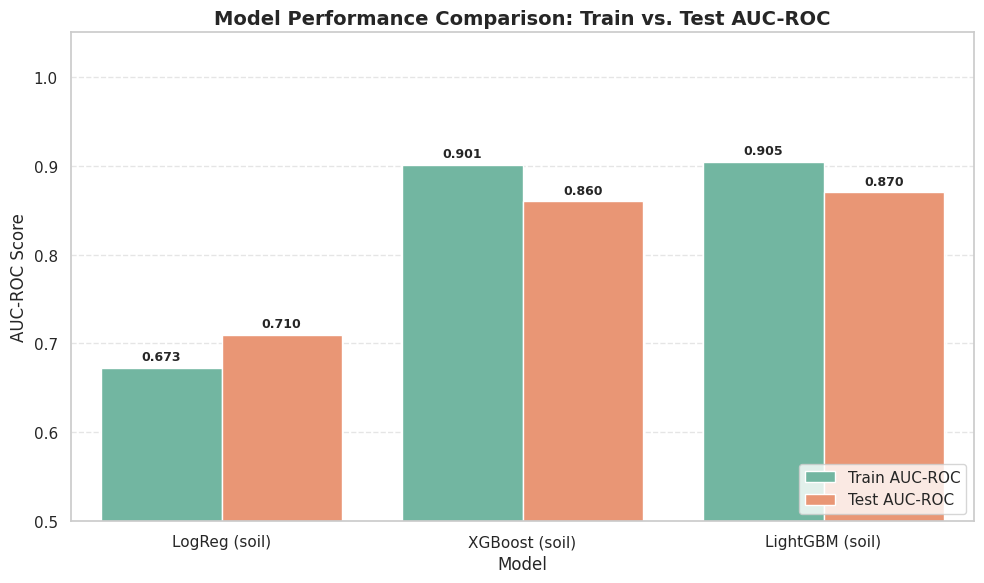

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
df_plot = df_auc_summary.melt(
    id_vars='Model',
    value_vars=['Train AUC-ROC', 'Test AUC-ROC'],
    var_name='Split',
    value_name='AUC-ROC'
)

# Plot side-by-side bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Model', y='AUC-ROC', hue='Split', palette='Set2')

plt.ylim(0.5, 1.05)
plt.title('Model Performance Comparison: Train vs. Test AUC-ROC', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('AUC-ROC Score', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

# Add values on top of the bars
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{height:.3f}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='center',
                            xytext=(0, 8),
                            textcoords='offset points',
                            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

*Comprehensive Train, Validation, and Test Performance Comparison*


,Model,Train AUC-ROC,Validation AUC-ROC,Test AUC-ROC
0,LogReg (soil),0.6726,0.6579,0.7096
1,XGBoost (soil),0.9013,0.8583,0.8600
2,LightGBM (soil),0.9046,0.8600,0.8699


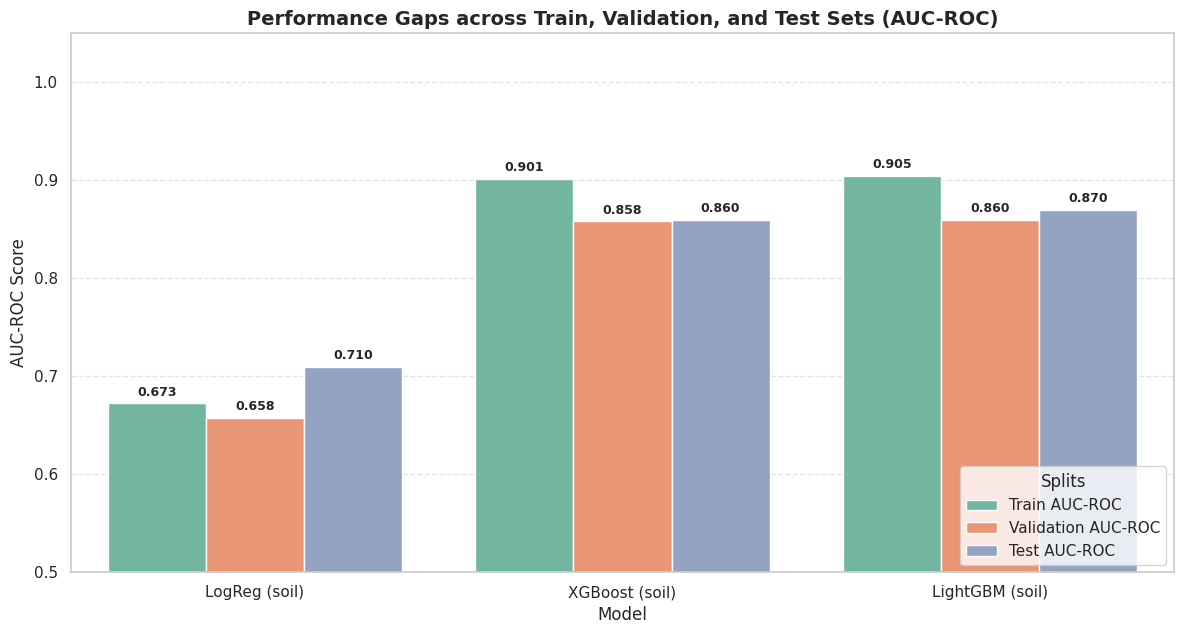

In [50]:
# 1. Prepare data holders
results_all_splits = []

# Define the splits mapped from previously defined indices
splits = {
    'Train': (idx_train, 'Train'),
    'Validation': (idx_val, 'Validation'),
    'Test': (idx_test, 'Test')
}

# 2. Extract AUC-ROC scores across all three splits
for name, (feats, model_name) in EXPERIMENTS.items():
    if 'coords' in name:
        continue  # Keep focused on soil features

    # Fit on training set
    model = FACTORY[model_name]().fit(df_clean.iloc[idx_train][feats], y_full[idx_train])

    row = {'Model': name}
    for split_name, (idx_split, _) in splits.items():
        p = model.predict_proba(df_clean.iloc[idx_split][feats])[:, 1]
        auc = roc_auc_score(y_full[idx_split], p)
        row[f'{split_name} AUC-ROC'] = auc

    results_all_splits.append(row)

df_splits_summary = pd.DataFrame(results_all_splits).round(4)
display(df_splits_summary)

# 3. Reshape for visualization
df_plot_three = df_splits_summary.melt(
    id_vars='Model',
    value_vars=['Train AUC-ROC', 'Validation AUC-ROC', 'Test AUC-ROC'],
    var_name='Split',
    value_name='AUC-ROC'
)

# 4. Generate the graph
plt.figure(figsize=(12, 6.5))
sns.barplot(data=df_plot_three, x='Model', y='AUC-ROC', hue='Split', palette='Set2')

plt.ylim(0.5, 1.05)
plt.title('Performance Gaps across Train, Validation, and Test Sets (AUC-ROC)', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('AUC-ROC Score', fontsize=12)
plt.legend(loc='lower right', frameon=True, title='Splits')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

# Annotate scores
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{height:.3f}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='center',
                            xytext=(0, 8),
                            textcoords='offset points',
                            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()